# CT Power Harvesting: Response to Line Current

## Question
How does harvested power respond to line current and does CT
construction (bobbin vs bare) affect it?

### Background

A current transformer (CT) clamps around a conductor and harvests power from the magnetic field produced by the current flowing through it. AS the primary current increases there is an increase in flux which results in more induced power in the CT. In developing low power IoT Sensors for the electrical grid harvesting meaningful power at low primary currents is of high importance.

### Setup

This notebook uses ct_data and ct_plots src/ modules for loading and plotting. 
Analysis logic lives there while narrative is contained in the notebook.

In [12]:
%load_ext autoreload
%autoreload 2

import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.append("../src")
from ct_data import load_benchmarks, load_trial
from ct_plots import (
    compare_sweeps,
    compare_sweeps_grouped,
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Data and method

Each trial is recorded as a single CSV in `data/raw/` named `trial_NNN_YYYY-MM-DD.csv`. In these trials current is swept while clamping force and load voltage are held (once sufficient power is generated) and harvested power is the measured response.

Loading and validation are handled by `load_trial()` in `ct_data.py`: it reads the raw CSV, derives `power_mW` from output current and load voltage and validates the schema before returning. Plotting goes through `ct_plots.py` which applies one house style so every figure is comparable.

## Findings

### Power increases with line current



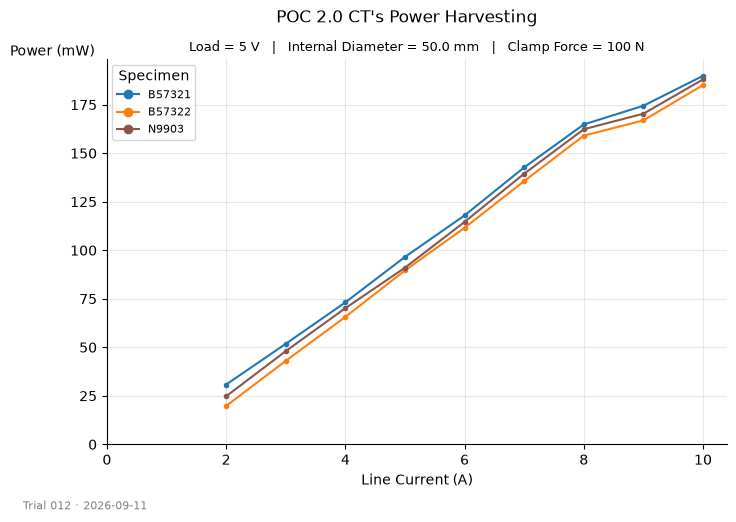

In [13]:
fig, ax = compare_sweeps(
    ["012"],
    x="line_current_A",
    xlabel="Line Current (A)",
)
fig.suptitle("POC 2.0 CT's Power Harvesting")
fig.savefig("../figures/compare_012_full.png", dpi=300, bbox_inches="tight")

### The response is consistent across specimens regardless of whether they are integrated into a bobbin.

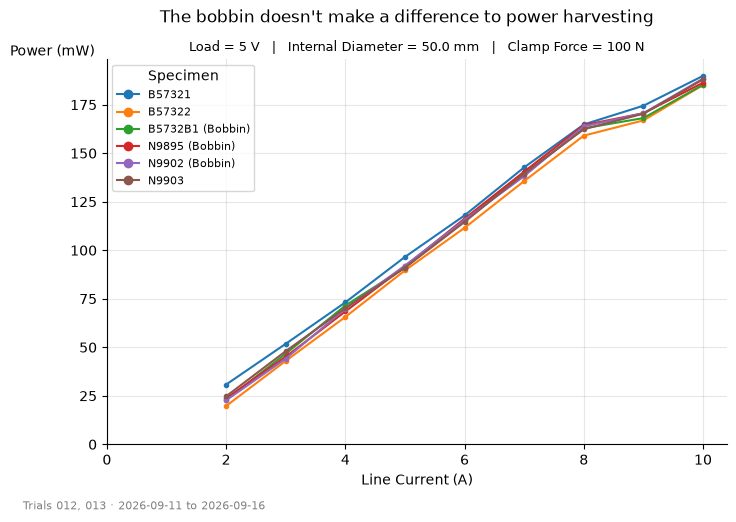

In [14]:
fig, ax = compare_sweeps(
    ["012", "013"],
    x="line_current_A",
    xlabel="Line Current (A)",
)
fig.suptitle("The bobbin doesn't make a difference to power harvesting")
fig.savefig("../figures/compare_012_013_full.png", dpi=300, bbox_inches="tight")

### Next steps

- Integrate the POC 2.0 CT geometry with the Screw Clamp into an enclosure and test it across a range of low primary current (2 - 10A)